## Importing Required Libraries

In [240]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing(Training Image Preprocessing)

In [243]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 13104 files belonging to 15 classes.


## Validation Image Preprocessing

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 300 files belonging to 15 classes.


In [7]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 15), dtype=tf.float32, name=None))>

In [8]:
for x,y in training_set:
    print (x,x.shape)
    print (y,y.shape)
    break

tf.Tensor(
[[[[120.94531    143.94531     97.94531   ]
   [ 74.125       46.921875    29.648438  ]
   [ 69.296875    34.796875    22.671875  ]
   ...
   [ 67.078125   103.328125    57.203125  ]
   [ 72.125      104.875       60.046875  ]
   [ 66.61719    102.24219     58.367188  ]]

  [[ 75.77344     55.039062    33.9375    ]
   [ 71.25781     31.867188    21.5625    ]
   [ 72.          32.          20.        ]
   ...
   [ 75.6875     106.6875      64.6875    ]
   [ 70.4375     106.4375      60.0625    ]
   [ 69.6875     107.6875      58.6875    ]]

  [[ 68.35156     31.601562    19.976562  ]
   [ 73.140625    32.929688    23.        ]
   [ 71.3125      31.3125      21.3125    ]
   ...
   [ 76.17969    109.17969     66.17969   ]
   [ 74.         110.          64.        ]
   [ 76.22656    107.10156     60.476562  ]]

  ...

  [[ 75.          39.          27.        ]
   [ 76.375       39.625       26.984375  ]
   [ 77.          39.75        26.375     ]
   ...
   [171.80469    137.804

## Building Model

In [289]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [291]:
model = Sequential()

## Building Convolution Layer

In [294]:
model.add(tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)))

model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [296]:
model.add(Conv2D(filters=64,kernel_size=3,padding="same",activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [298]:
model.add(Conv2D(filters=128,kernel_size=3,padding="same",activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [300]:
model.add(Conv2D(filters=256,kernel_size=3,padding="same",activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

## Flattening Operation (Its Done to feed data to the neural network)

In [303]:
model.add(tf.keras.layers.Dropout(0.25)) #To Avoid Overfitting


In [305]:
model.add(Flatten())

In [307]:
 model.add(Dense(units=1024,activation="relu"))

In [309]:
model.add(tf.keras.layers.Dropout(0.5)) #To avoid overfitting


In [311]:
#Output Layer
model.add(Dense(units=15,activation="softmax"))

## Compiling Model

In [314]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [316]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │        15,375 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625,839 (40.53 MB)

 Trainable params: 10,625,839 (40.53 MB)

 Non-trainable params: 0 (0.00 B)

 ## Model Training

In [323]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)


Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 838s 2s/step - accuracy: 0.8357 - loss: 0.4983 - val_accuracy: 0.8300 - val_loss: 1.3382
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 848s 2s/step - accuracy: 0.8581 - loss: 0.4254 - val_accuracy: 0.8267 - val_loss: 1.6929
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 838s 2s/step - accuracy: 0.8779 - loss: 0.3594 - val_accuracy: 0.8967 - val_loss: 1.4076
Epoch 4/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 873s 2s/step - accuracy: 0.8918 - loss: 0.3283 - val_accuracy: 0.8733 - val_loss: 1.6086
Epoch 5/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 856s 2s/step - accuracy: 0.9022 - loss: 0.2969 - val_accuracy: 0.8967 - val_loss: 1.4391
Epoch 6/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 902s 2s/step - accuracy: 0.9135 - loss: 0.2565 - val_accuracy: 0.9067 - val_loss: 1.6680
Epoch 7/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1283s 3s/step - accuracy: 0.9241 - loss: 0.2319 - val_accuracy: 0.9067 - val_loss: 1.6431
Epoch 8/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 1505s 4s/step - accuracy: 0.9219 - loss: 0.2345 - val_ac

## Model Evaluation

In [326]:
# Model Evaluation on Training Set
train_loss,train_acc=model.evaluate(training_set)


410/410 ━━━━━━━━━━━━━━━━━━━━ 382s 931ms/step - accuracy: 0.9663 - loss: 0.0978


In [328]:
print('Training accuracy:', train_acc)

Training accuracy: 0.966269850730896


In [330]:
# Model Evaluation On Validation Set
val_loss,val_acc=model.evaluate(validation_set)


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 618ms/step - accuracy: 0.8967 - loss: 1.7364


In [332]:
print(val_loss,val_acc)

1.736403226852417 0.8966666460037231


## Saving Model

In [334]:
model.save("trained_model_10m.keras")

import json
class_name = training_set.class_names
with open('class_names.json', 'w') as f:
    json.dump(class_name, f)
print("Model and class names saved!")

Model and class names saved!


In [336]:
training_history.history #Return Dictionary of history


{'accuracy': [0.8356990218162537,
  0.858134925365448,
  0.8778998851776123,
  0.8917887806892395,
  0.9021672606468201,
  0.9134615659713745,
  0.9240689873695374,
  0.9218559265136719,
  0.9376526474952698,
  0.93482905626297],
 'loss': [0.4983433783054352,
  0.425354927778244,
  0.3594140410423279,
  0.3283126950263977,
  0.2969193756580353,
  0.2564859688282013,
  0.23188094794750214,
  0.2345457226037979,
  0.19830231368541718,
  0.19399602711200714],
 'val_accuracy': [0.8299999833106995,
  0.8266666531562805,
  0.8966666460037231,
  0.8733333349227905,
  0.8966666460037231,
  0.9066666960716248,
  0.9066666960716248,
  0.9166666865348816,
  0.8633333444595337,
  0.8966666460037231],
 'val_loss': [1.338171124458313,
  1.6928786039352417,
  1.407593846321106,
  1.608606219291687,
  1.4391428232192993,
  1.6679565906524658,
  1.6430585384368896,
  1.6632355451583862,
  1.7183057069778442,
  1.736403226852417]}

In [342]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [344]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

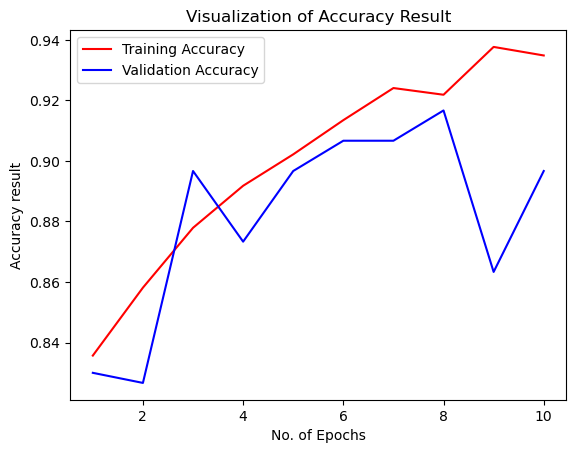

In [347]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy result')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some Other Metrics For Model Evaluation

In [350]:
class_name = validation_set.class_names
class_name

['aphid_valid',
 'black_rust_valid',
 'blast_test_valid',
 'brown_rust_valid',
 'common_root_rot_valid',
 'fusarium_head_blight_valid',
 'healthy_valid',
 'leaf_blight_valid',
 'mildew_valid',
 'mite_valid',
 'septoria_valid',
 'smut_valid',
 'stem_fly_valid',
 'tan_spot_valid',
 'yellow_rust_valid']

In [352]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 300 files belonging to 15 classes.


In [354]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

300/300 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step


(array([[9.92254972e-01, 1.96144556e-05, 4.17252366e-08, ...,
         1.22343145e-05, 6.31553470e-04, 7.64264144e-07],
        [9.95454431e-01, 3.58694851e-05, 1.52272708e-03, ...,
         8.30605586e-06, 3.04096437e-04, 4.11468726e-08],
        [9.94753599e-01, 2.88216688e-04, 4.75331508e-05, ...,
         1.84702134e-04, 9.80457757e-04, 2.29914833e-04],
        ...,
        [5.66261235e-07, 3.54943532e-14, 1.13116669e-13, ...,
         4.25375338e-14, 4.03290526e-11, 9.99999404e-01],
        [1.21422539e-09, 5.91482472e-15, 5.16463174e-12, ...,
         1.16312142e-16, 2.09651990e-10, 9.99999881e-01],
        [1.43236734e-09, 1.11903835e-21, 1.02489086e-22, ...,
         1.87193687e-20, 1.17459022e-15, 1.00000000e+00]], dtype=float32),
 (300, 15))

In [356]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories 

<tf.Tensor: shape=(300,), dtype=int64, numpy=
array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, 13,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3, 10,  3,  3,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5, 14, 14, 14, 14, 14, 14, 14,  1, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 13,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7, 13,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  3,  8,  8,  0,  9,  9,  9,  0, 13,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  3,  9,  3, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10,  7, 10, 10, 10, 10,

In [358]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(300, 15), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [360]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(300,), dtype=int64, numpy=
array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,

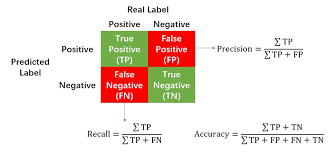!

In [363]:
from sklearn.metrics import classification_report, confusion_matrix

In [365]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                            precision    recall  f1-score   support

               aphid_valid       0.91      1.00      0.95        20
          black_rust_valid       0.95      0.95      0.95        20
          blast_test_valid       1.00      1.00      1.00        20
          brown_rust_valid       0.86      0.95      0.90        20
     common_root_rot_valid       1.00      1.00      1.00        20
fusarium_head_blight_valid       1.00      1.00      1.00        20
             healthy_valid       0.00      0.00      0.00        20
         leaf_blight_valid       0.90      0.95      0.93        20
              mildew_valid       1.00      0.95      0.97        20
                mite_valid       1.00      0.75      0.86        20
            septoria_valid       0.95      0.95      0.95        20
                smut_valid       1.00      1.00      1.00        20
            stem_fly_valid       1.00      1.00      1.00        20
            tan_spot_valid       0.83      0.95

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [367]:
cm = confusion_matrix(Y_true,predicted_categories)
cm


array([[20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 19,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 19,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1, 18],
       [ 0,  0,  0,  0,  0,  0,  0, 19,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0, 19,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  2,  0,  0,  0,  0,  0, 15,  0,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1,  0,  0, 19,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0, 19,  0],
       [ 0,  0,  0,  0,  0,  0,  0

## Confusion Matrix Visualization

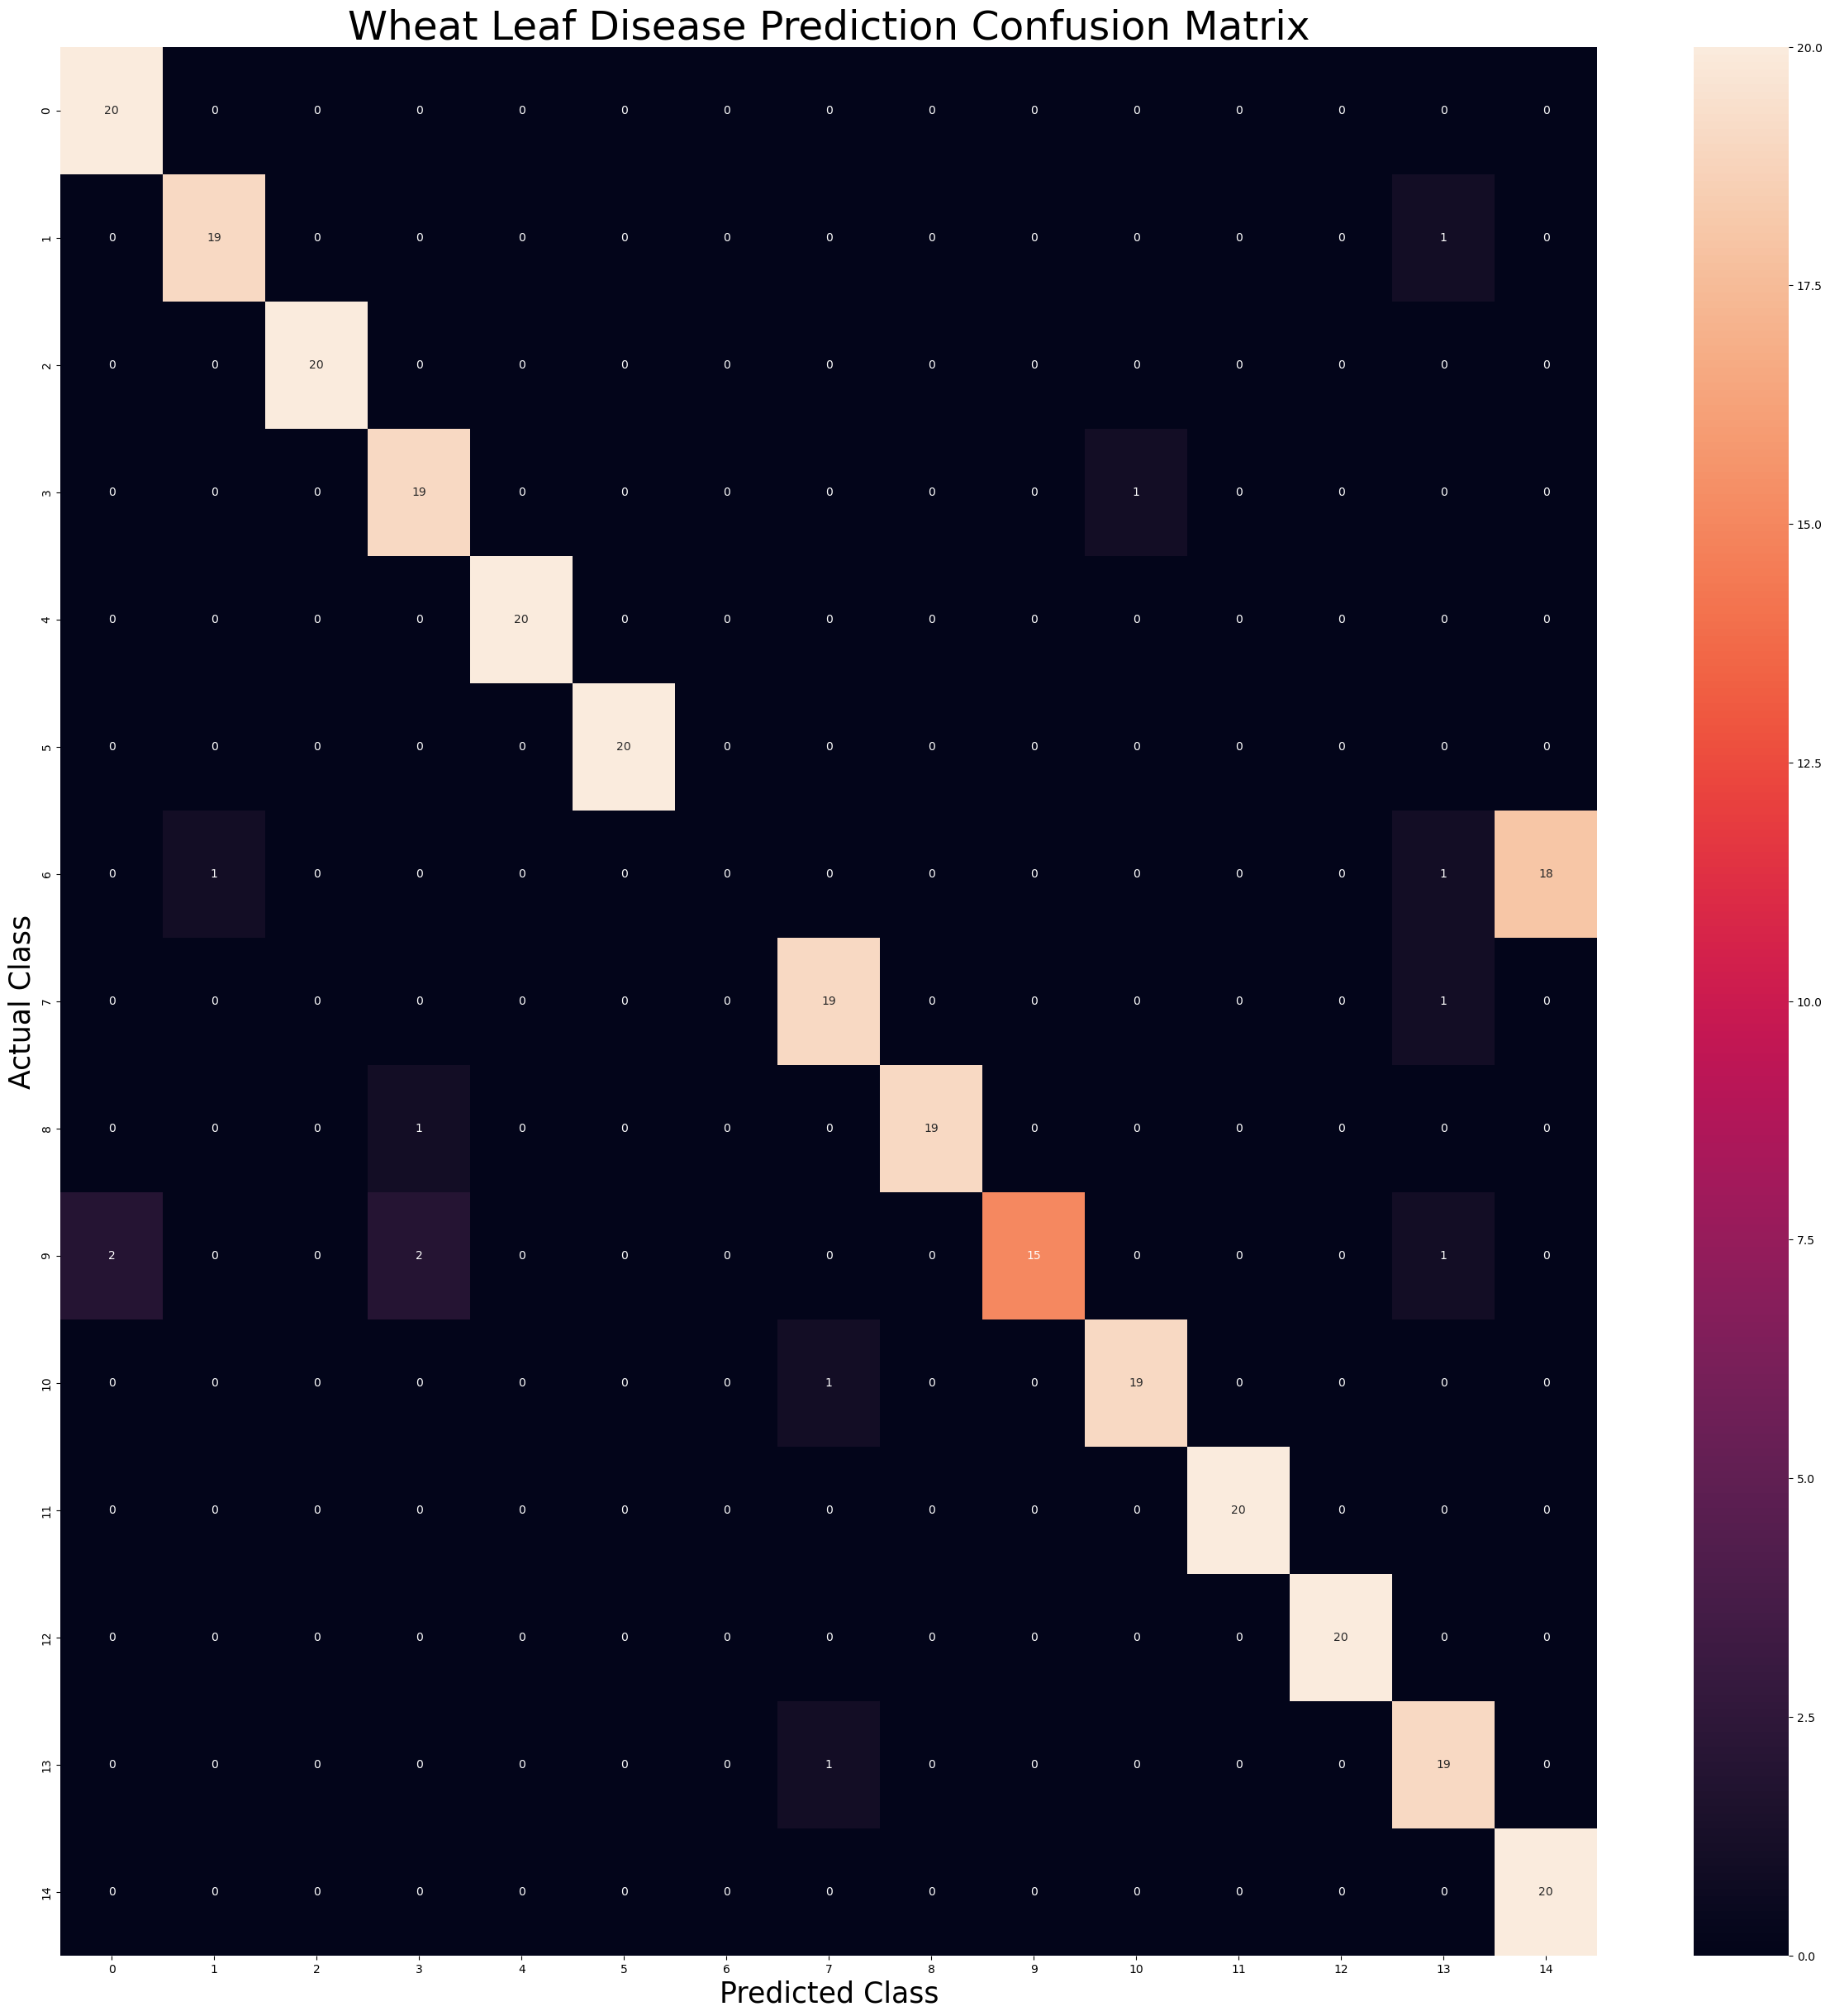

In [370]:
plt.figure(figsize=(30, 30))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 25)
plt.ylabel('Actual Class',fontsize = 25)
plt.title('Wheat Leaf Disease Prediction Confusion Matrix',fontsize = 35)
plt.show()